## Importções e leitura dos stats

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
with open(r"matrix_multiplication\data\stats.json", "r", encoding="utf8") as f:
    data = json.load(f)

In [ ]:
records = []
for entry in data:
    for key, value in entry.items():
        value["type"] = key
        records.append(value)

df = pd.DataFrame(records)

In [ ]:
# Normalizar colunas ausentes
for col in ["num_cores", "num_servers", "block_size"]:
    if col not in df.columns:
        df[col] = None

df["num_cores"] = df["num_cores"].fillna(df["num_servers"])
df = df.drop(columns=["num_servers"], errors="ignore")

# Ordenar
df = df.sort_values(["type", "block_size", "num_cores"]).reset_index(drop=True)

print("=== TABELA ORIGINAL ===")
print(df[["type", "num_cores", "block_size", "time_seconds"]])

=== TABELA ORIGINAL ===
             type  num_cores  block_size  time_seconds
0   Blocked local          1         128    128.502636
1   Blocked local          2         128     72.352800
2   Blocked local          4         128     42.954266
3   Blocked local          6         128     35.033347
4   Blocked local          8         128     30.545650
5   Blocked local         10         128     29.067674
6   Blocked local         12         128     27.808154
7   Blocked local          1         256    118.307509
8   Blocked local          2         256     72.965026
9   Blocked local          4         256     49.395249
10  Blocked local          6         256     37.935167
11  Blocked local          8         256     31.553169
12  Blocked local         10         256     28.631263
13  Blocked local         12         256     30.043067
14  Blocked local          1         512    112.326914
15  Blocked local          2         512     95.600444
16  Blocked local          4         512 

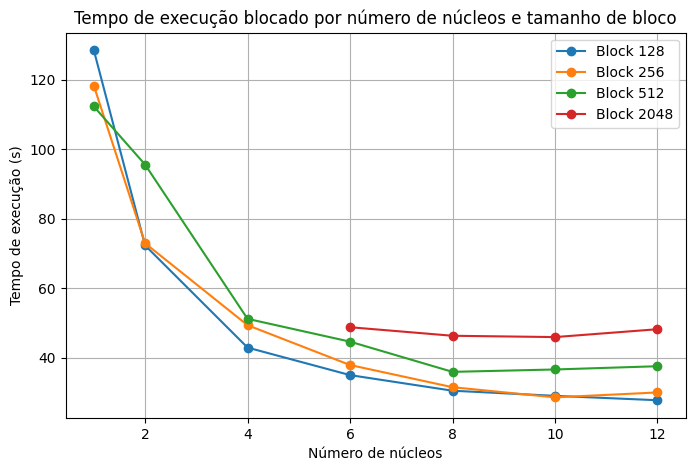

In [ ]:
df_blocked = df[df['type'] != 'Linear'].copy()

plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["time_seconds"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Tempo de execução (s)")
plt.title("Tempo de execução blocado por número de núcleos e tamanho de bloco")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
t1_linear = df.loc[df["type"] == "Linear", "time_seconds"].values[0]
t1_blocked128 = df.loc[
    (df["type"] == "Blocked local") & (df["block_size"] == 128) & (df["num_cores"] == 1),
    "time_seconds",
].values[0]

df_blocked128 = df[
    (df["type"] == "Blocked local") &
    (df["block_size"] == 128)
].copy()

In [ ]:
def compute_metrics(df, base_time):
    df = df.copy()
    df["speedup"] = base_time / df["time_seconds"]
    df["efficiency"] = df["speedup"] / df["num_cores"]
    return df


In [ ]:
df_linear_base = compute_metrics(df, t1_linear)
df_blocked128 = compute_metrics(df, t1_blocked128)

In [ ]:
def summary_table(df, label):
    print(f"\n=== MÉTRICAS USANDO BASE: {label} ===")
    print(
        df[["type", "num_cores", "block_size", "time_seconds", "speedup", "efficiency"]]
        .round(3)
        .to_string(index=False)
    )

In [ ]:
summary_table(df_linear_base, "Linear")


=== MÉTRICAS USANDO BASE: Linear ===
         type  num_cores  block_size  time_seconds  speedup  efficiency  redundancy
Blocked local          1         128       128.503    5.751       5.751       0.174
Blocked local          2         128        72.353   10.214       5.107       0.196
Blocked local          4         128        42.954   17.205       4.301       0.232
Blocked local          6         128        35.033   21.095       3.516       0.284
Blocked local          8         128        30.546   24.194       3.024       0.331
Blocked local         10         128        29.068   25.424       2.542       0.393
Blocked local         12         128        27.808   26.576       2.215       0.452
Blocked local          1         256       118.308    6.247       6.247       0.160
Blocked local          2         256        72.965   10.128       5.064       0.197
Blocked local          4         256        49.395   14.961       3.740       0.267
Blocked local          6         256  

In [ ]:
summary_table(df_blocked128, "Blocked local 128")


=== MÉTRICAS USANDO BASE: Blocked local 128 ===
         type  num_cores  block_size  time_seconds  speedup  efficiency  redundancy
Blocked local          1         128       128.503    1.000       1.000       1.000
Blocked local          2         128        72.353    1.776       0.888       1.126
Blocked local          4         128        42.954    2.992       0.748       1.337
Blocked local          6         128        35.033    3.668       0.611       1.636
Blocked local          8         128        30.546    4.207       0.526       1.902
Blocked local         10         128        29.068    4.421       0.442       2.262
Blocked local         12         128        27.808    4.621       0.385       2.597
Blocked local          1         256       118.308    1.086       1.086       0.921
Blocked local          2         256        72.965    1.761       0.881       1.136
Blocked local          4         256        49.395    2.602       0.650       1.538
Blocked local          6   

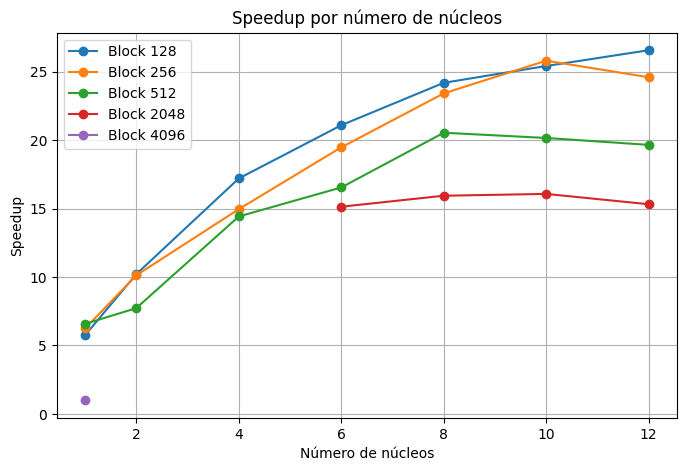

In [ ]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_linear_base.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["speedup"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Speedup")
plt.title("Speedup por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()

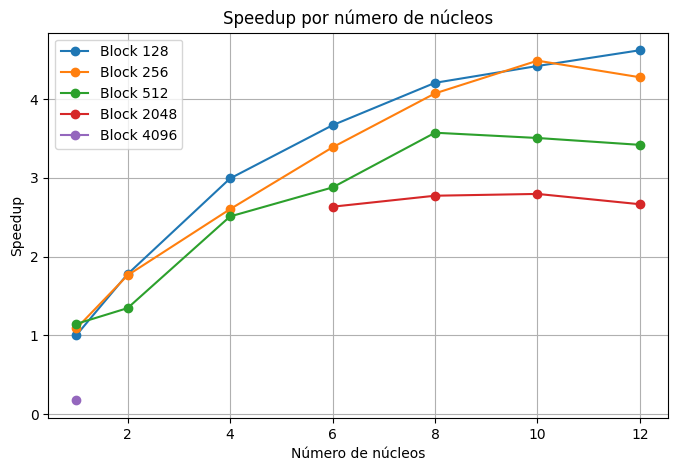

In [ ]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked128.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["speedup"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Speedup")
plt.title("Speedup por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()

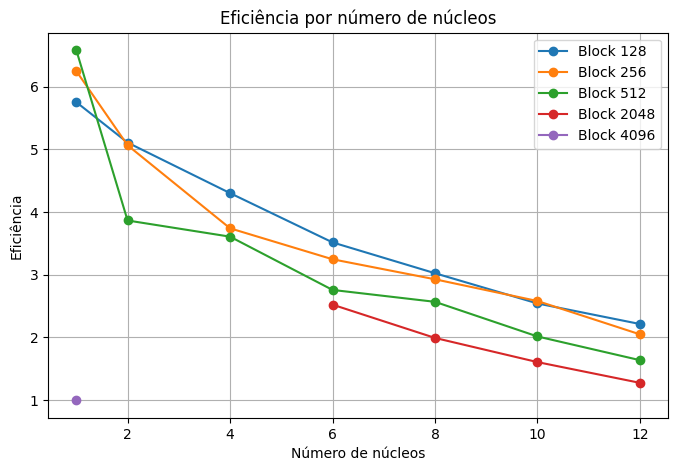

In [ ]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_linear_base.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["efficiency"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Eficiência")
plt.title("Eficiência por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()


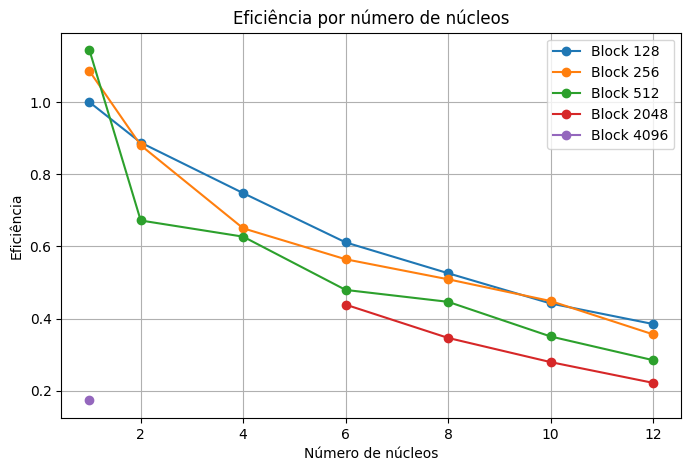

In [ ]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked128.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["efficiency"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Eficiência")
plt.title("Eficiência por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()